Processed data is stored in pkl file<br>
Load data anbd fit with PyMC<br>
Pt100 KOH CO oxidation<br>
<br>
Models:<br> 
<br>
A) ER:<br> 
1. CO + * -> CO*<br> 
2. CO* + OH- -> COOH* + e-<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle 
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import itertools

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
conditions = list(itertools.product(C_KOH_list, P_CO_list))
R, T, F = 8.3145, 298.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K 

# Load and parse data
with open('Pt100_KOH.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)
E_obs = experiments_interp[(0.1, 0.1)]['E'] # V vs SHE - random conditions

alpha_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        alpha_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['alpha']

delta_OH_obs = np.zeros((len(P_CO_list), len(E_obs)))
for j, P_CO in enumerate(P_CO_list):
    delta_OH_obs[j, :] = experiments_interp[(0.1, P_CO)]['delta_OH'] # Random C_KOH

delta_CO_obs = np.zeros((len(C_KOH_list), len(P_CO_list)-1, len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list[:-1]): 
        delta_CO_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['delta_CO']

# Constructing variables to make it more feasible for models
# Variables reshaped for broadcasting
dE = E_obs[1] - E_obs[0]
d_ln_P_CO = np.diff(np.log(P_CO_list))[None, :, None]

# Need this because np.polyfit doesn't work with pymc variables - used for delta_OH
ln_C = np.log(C_KOH_list)
ln_C_mean = np.mean(ln_C)
S_xx = np.sum((ln_C - ln_C_mean)**2)
w_C = (ln_C - ln_C_mean) / S_xx
w_C_in = w_C[:, None, None]

C_KOH_in = C_KOH_list[:, None, None] # Shape (N, 1, 1)
P_CO_in = P_CO_list[None, :, None] # Shape (1, N, 1)
E_in = E_obs[None, None, :] # Shape (1, 1, N)

def calc_observables(log_rate): 
    '''
    Converts a raw rate tensor (C_KOH, P_CO, E) into kinetic observables (alpha, delta_OH, delta_CO).
    Returns PyTensor variables ready for the model.
    '''
    # Alpha with central difference (forward/backward difference at edges - no points lost)
    d_log_rate_dE = pt.zeros_like(log_rate)

    d_log_rate_center_dE = (log_rate[:, :, 2:] - log_rate[:, :, :-2]) / (2*dE)
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 1:-1], d_log_rate_center_dE)

    d_log_rate_start_dE = (log_rate[:, :, 1] - log_rate[:, :, 0]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 0], d_log_rate_start_dE)
    
    d_log_rate_end_dE = (log_rate[:, :, -1] - log_rate[:, :, -2]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, -1], d_log_rate_end_dE)

    mu_alpha = (R*T/F) * d_log_rate_dE

    # Delta OH with linear regression: weights set up earlier
    mu_delta_OH = pm.math.sum(w_C_in * log_rate, axis=0)

    # Delta CO with finite difference, losing a P_CO point
    d_log_rate_P = log_rate[:, 1:, :] - log_rate[:, :-1, :]
    mu_delta_CO = d_log_rate_P / d_ln_P_CO

    return mu_alpha, mu_delta_OH, mu_delta_CO

def get_combined_loo(idata):
    """
    Merges multiple log-likelihood variables into a single array 
    and calculates the global LOO score, preserving the posterior for Reff.
    """
    ll_list = []
    
    # Loop through each observed variable
    for var_name in idata.log_likelihood.data_vars:
        da = idata.log_likelihood[var_name]

        # Identify experimental (controlled) dimensions
        obs_dims = [d for d in da.dims if d not in ('chain', 'draw')]

        # Flatten the experimental dims into a single 'obs' dimension
        if obs_dims: da_flat = da.stack(observations=obs_dims)
        else: da_flat = da.expand_dims(observations=1) # Handle scalars if any
            
        # Drop the coordinate labels (MultiIndex) so we can concatenate cleanly
        da_flat = da_flat.reset_index('observations', drop=True)
        ll_list.append(da_flat)
        
    # Concatenate all variables along the 'observations' dimension and give distinct indices
    combined_ll = xr.concat(ll_list, dim='observations')
    combined_ll = combined_ll.assign_coords(observations=range(combined_ll.sizes['observations']))
    
    # Create a new InferenceData object that has the new Likelihood AND the original Posterior
    new_idata = az.InferenceData(
        posterior=idata.posterior,  # Required for N_eff / Reff calculations
        log_likelihood=combined_ll.to_dataset(name='total_model')
    )
    
    return az.loo(new_idata, var_name='total_model', pointwise=True)

def calculate_flattened_r2(ppc, var_name):
    # 1. Get the real data and model predictions
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    
    # y_true shape: (N_Conc, N_Pres, N_Volt) -> e.g., (1, 5, 20)
    # y_pred shape: (Chains, Draws, N_Conc, N_Pres, N_Volt)
    
    # 2. Flatten the dimensions so ArviZ sees a simple list of points
    # New y_true: (100,)
    y_true_flat = y_true.flatten()
    
    # New y_pred: (Chains, Draws, 100)
    # We keep the first two dims (Chains, Draws) and flatten the rest
    chains, draws = y_pred.shape[:2]
    y_pred_flat = y_pred.reshape(chains * draws, -1)
    
    # 3. Calculate R2
    r2 = az.r2_score(y_true_flat, y_pred_flat)
    return r2['r2']

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.39,15
,3000,0,0.32,15
,3000,0,0.36,7
,3000,0,0.32,7


Computed from 4000 posterior samples and 6400 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3391.60    74.14
p_loo        5.43        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6400  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



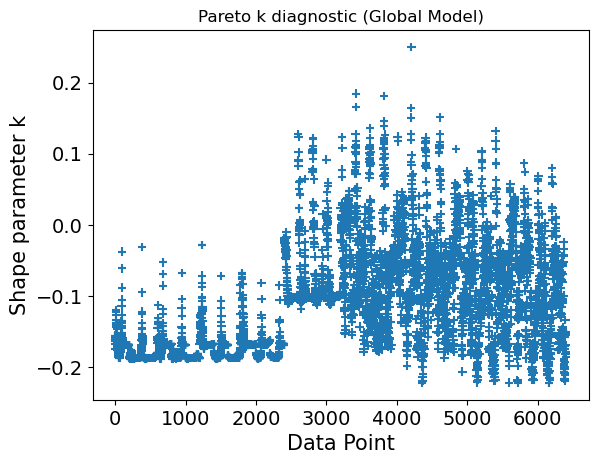

In [2]:
# Eley-Rideal Model - 3rd step is RDS  
with pm.Model() as ER_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) 
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    '''
    # Priors
    beta = pm.Uniform('beta', lower=0, upper=1)
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.2, sigma=0.1) 
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.1) # at 0V_SHE
    Gact3_0 = pm.Normal('Gact3_0', mu=0.6, sigma=0.2) # at 0V_SHE
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=0.05)
    sigma_delta_OH = pm.HalfNormal('sigma_delta_OH', sigma=0.05)
    sigma_delta_CO = pm.HalfNormal('sigma_delta_CO', sigma=0.05)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    Gact3 = Gact3_0 - beta*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_COOH = log_K2 + term_CO + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_COOH]), axis=0) # Stupid things being done to make shapes broadcast correctly
    log_theta_CO = term_CO + log_theta
    log_term_COOH = term_COOH + log_theta

    # Rate expression
    log_rate = log_k3 + log_term_COOH + np.log(C_KOH_in)

    # Observables
    mu_alpha, mu_delta_OH, mu_delta_CO = calc_observables(log_rate)
    alpha = pm.StudentT('alpha', nu=4, mu=mu_alpha, sigma=sigma_alpha, observed=alpha_obs)
    delta_OH = pm.StudentT('delta_OH', nu=4, mu=mu_delta_OH, sigma=sigma_delta_OH, observed=delta_OH_obs)
    delta_CO = pm.StudentT('delta_CO', nu=4, mu=mu_delta_CO, sigma=sigma_delta_CO, observed=delta_CO_obs)

# Run model fit and view results 
compile = nutpie.compile_pymc_model(ER_3)
trace = nutpie.sample(compile, 
                      draws=1000, 
                      tune=2000, 
                      chains=4, 
                      cores=2, 
                      target_accept=0.95,
                      )
pm.compute_log_likelihood(trace, progressbar=False, model=ER_3, compile_kwargs={"mode": "FAST_COMPILE"}) 

loo_ER_3 = get_combined_loo(trace)
print(loo_ER_3)
az.plot_khat(loo_ER_3)
plt.title("Pareto k diagnostic (Global Model)"); plt.show()

                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta            0.068  0.005   0.058    0.078      0.000    0.000    2922.0    2595.0    1.0
deltaG1_0      -0.299  0.059  -0.408   -0.211      0.002    0.002    1769.0    1358.0    1.0
deltaG2_0      -0.281  0.002  -0.286   -0.277      0.000    0.000    2843.0    2913.0    1.0
Gact3_0         0.599  0.195   0.228    0.966      0.003    0.003    4593.0    3067.0    1.0
sigma_alpha     0.206  0.003   0.200    0.212      0.000    0.000    3849.0    2908.0    1.0
sigma_delta_OH  0.715  0.019   0.678    0.750      0.000    0.000    4354.0    3059.0    1.0
sigma_delta_CO  0.439  0.008   0.423    0.454      0.000    0.000    4218.0    2903.0    1.0


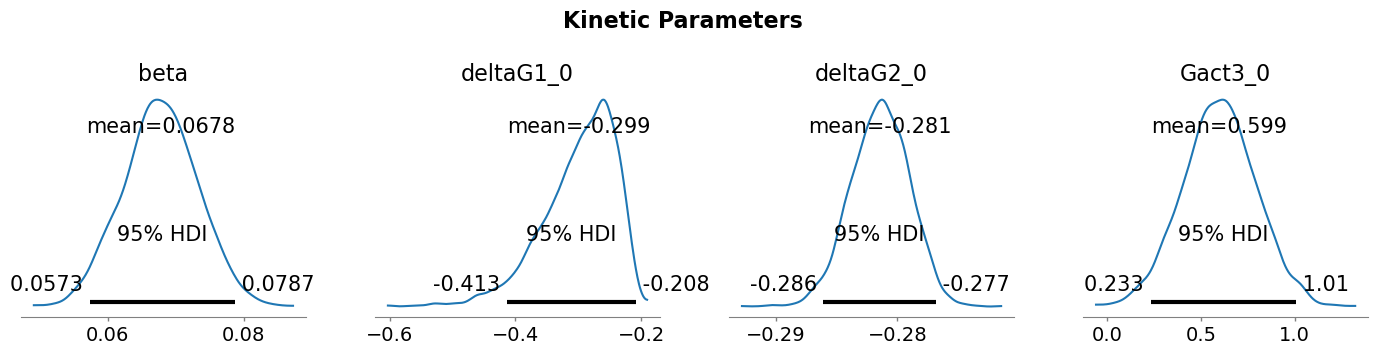

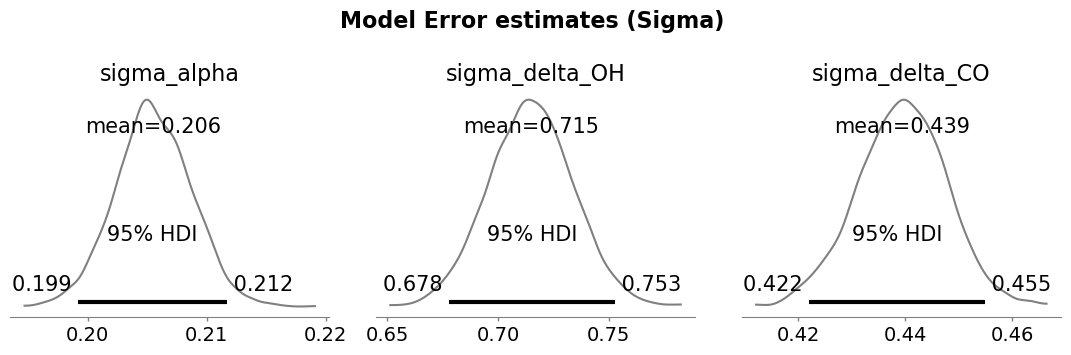

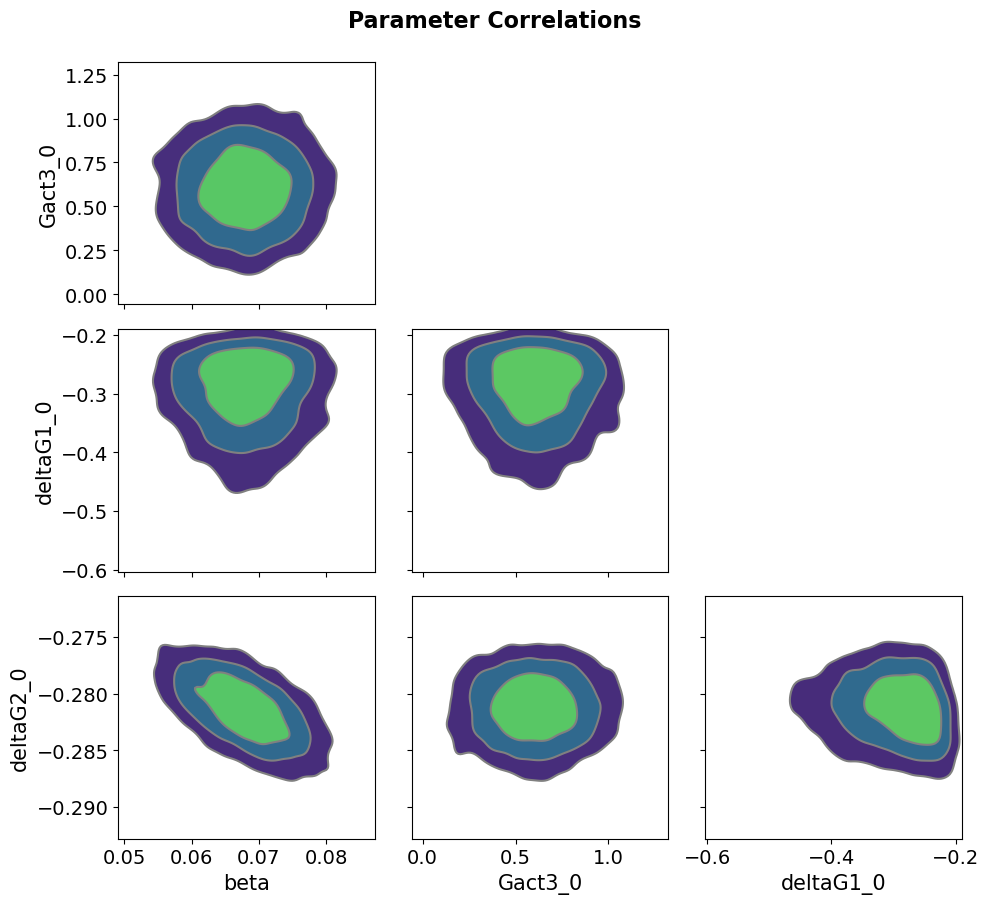

Sampling: [alpha, delta_CO, delta_OH]



--- Bayesian R2 Scores ---
alpha: 0.400
delta_OH: 0.417
delta_CO: 0.410


In [3]:
# Check data fit
with ER_3:

    summary = az.summary(trace, var_names=['beta', 'deltaG1_0', 'deltaG2_0', 'Gact3_0',
                                            'sigma_alpha', 'sigma_delta_OH', 'sigma_delta_CO'])
    print(summary)

    ax = az.plot_posterior(trace, var_names=['beta', 'deltaG1_0', 'deltaG2_0', 'Gact3_0'], 
                        hdi_prob=0.95, round_to=3, figsize=(14, 3.5))
    plt.suptitle("Kinetic Parameters", y=1, fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

    ax = az.plot_posterior(trace, var_names=['sigma_alpha', 'sigma_delta_OH', 'sigma_delta_CO'], 
                        hdi_prob=0.95, round_to=3, figsize=(11, 3.5), color='grey')
    plt.suptitle("Model Error estimates (Sigma)", y=1, fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

    ax = az.plot_pair(trace, var_names=['beta', 'Gact3_0', 'deltaG1_0', 'deltaG2_0',], 
                        kind='kde', divergences=True, figsize=(10, 9))
    plt.suptitle("Parameter Correlations", y=1, fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

    ppc = pm.sample_posterior_predictive(trace, progressbar=False, compile_kwargs={"mode": "FAST_COMPILE"})

    print("\n--- Bayesian R2 Scores ---")
    for var_name in ['alpha', 'delta_OH', 'delta_CO']:
        print(f"{var_name}: {calculate_flattened_r2(ppc, var_name):.3f}")

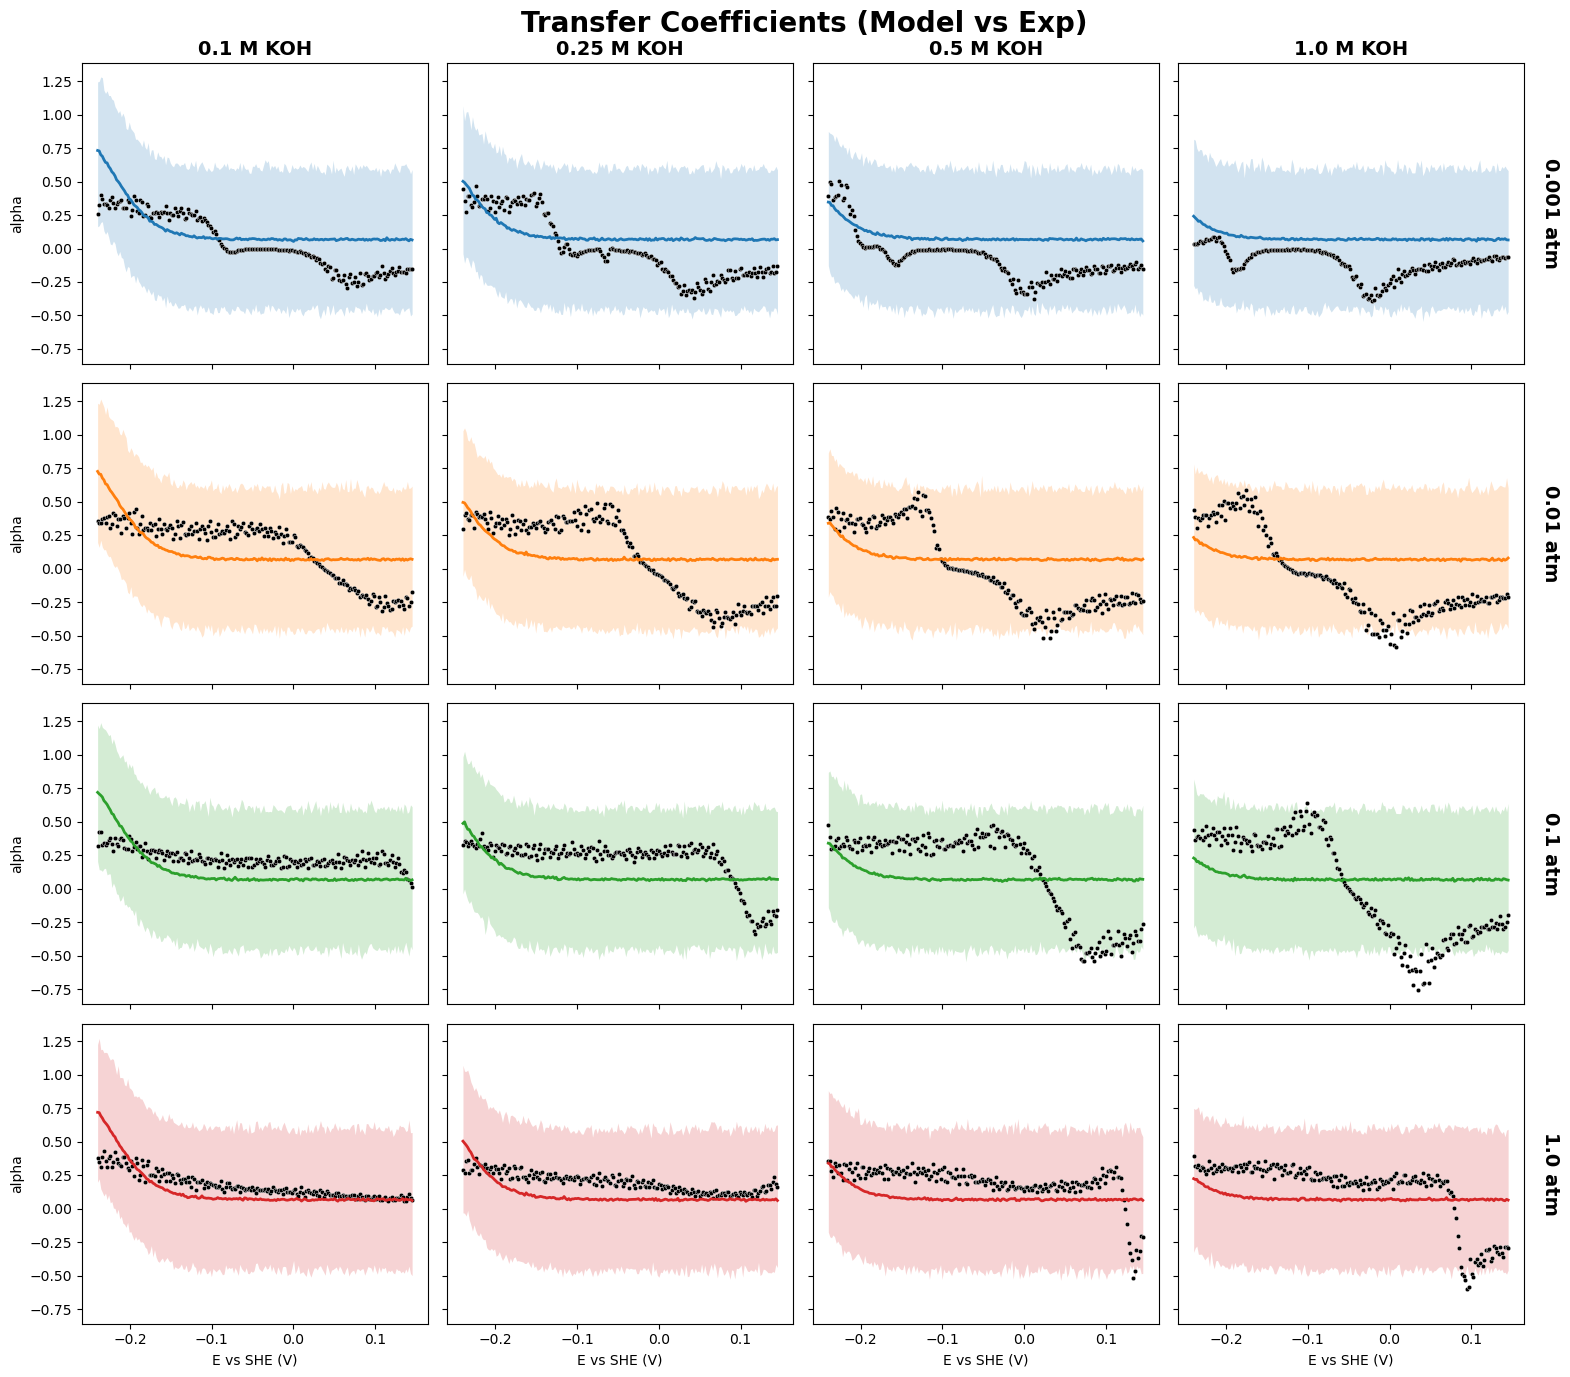

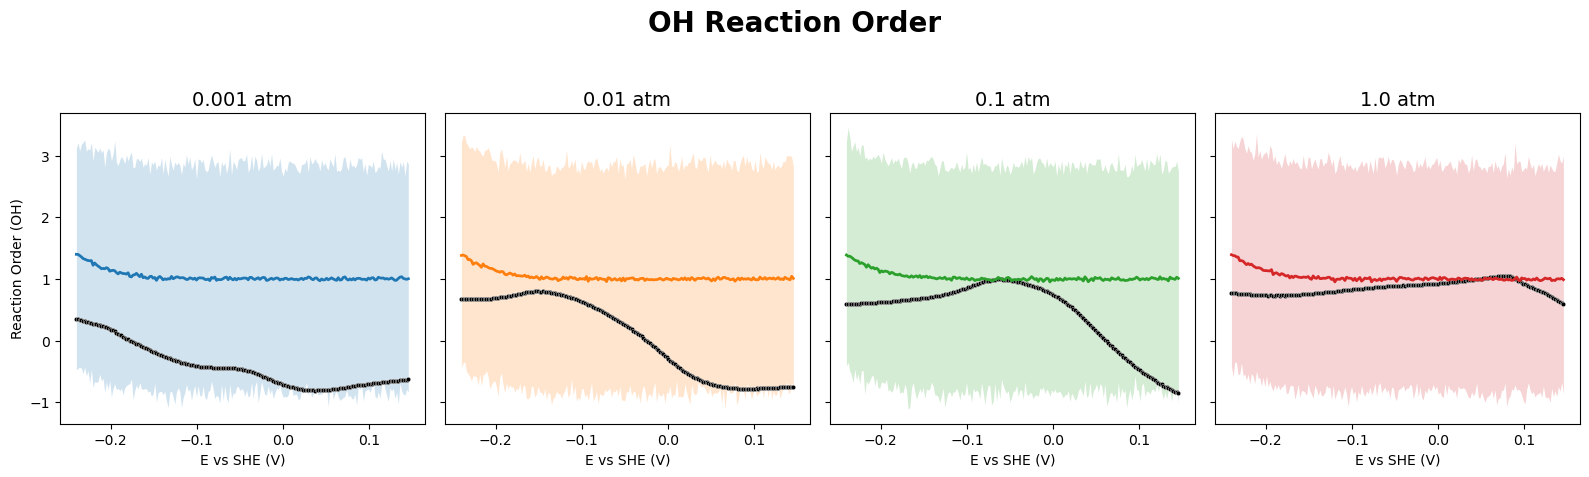

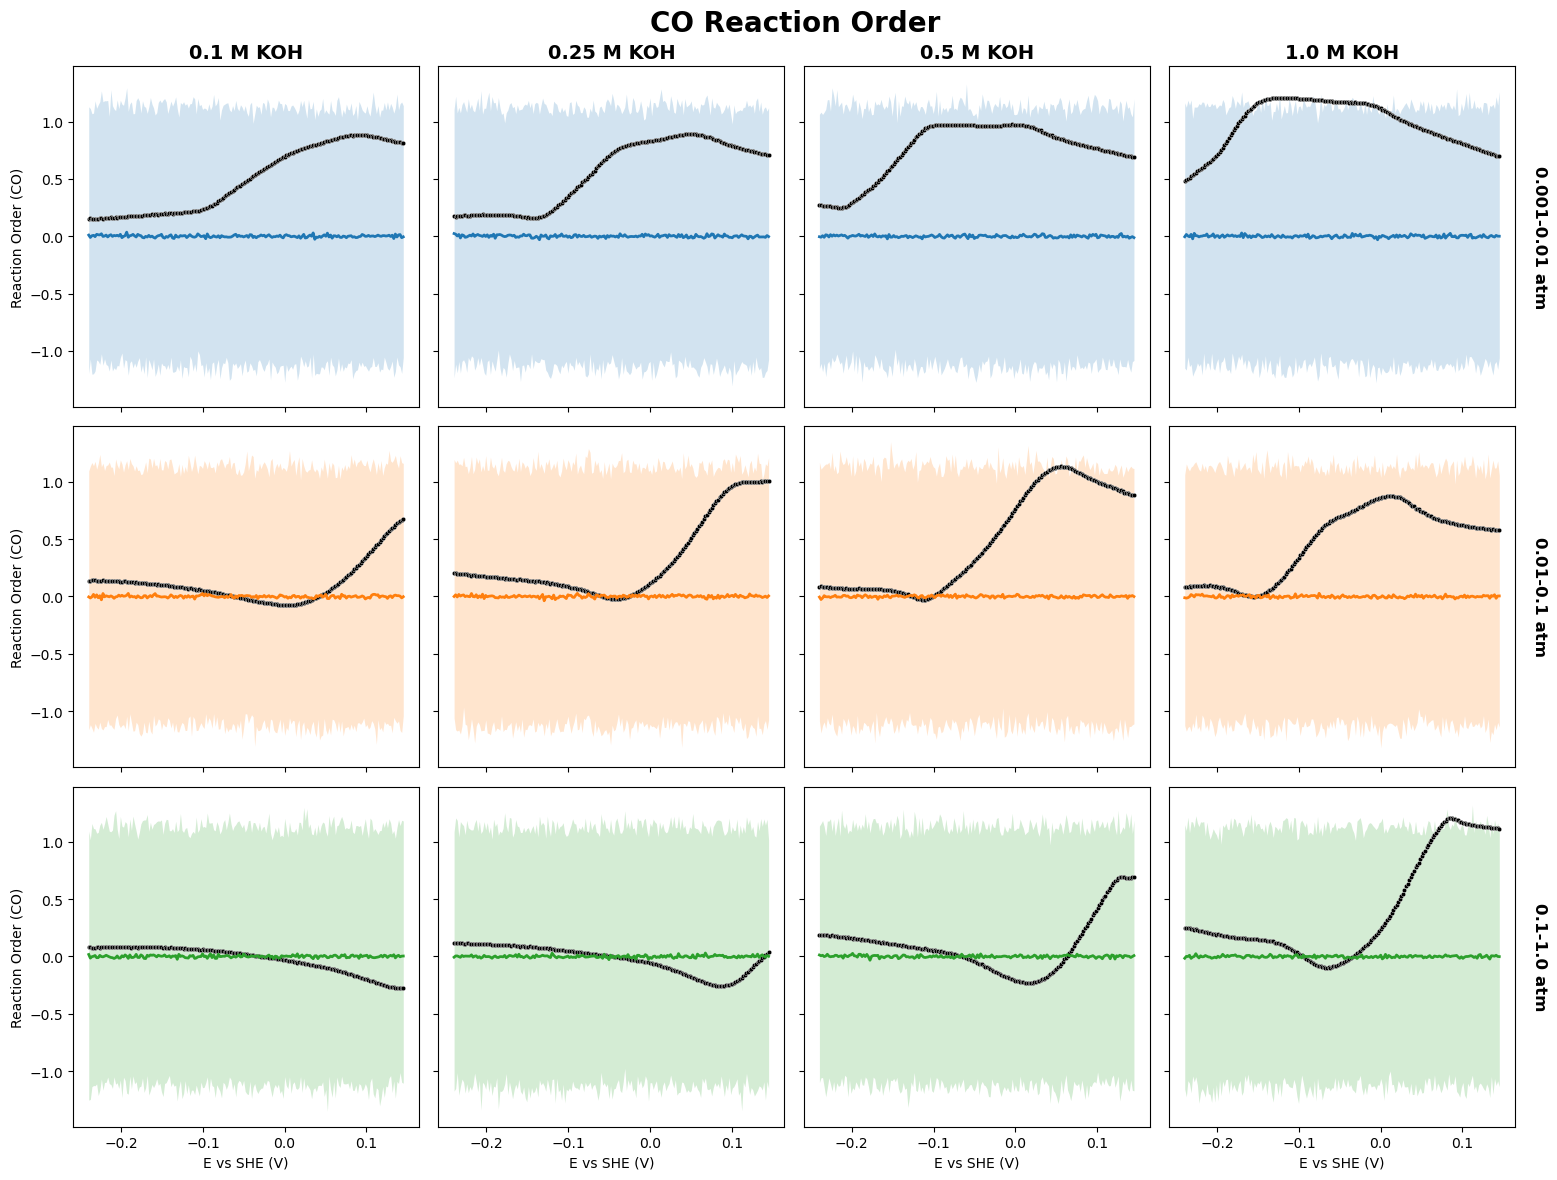

In [4]:
colors = plt.cm.tab10.colors[:len(P_CO_list)]

# --- 1. Transfer Coefficients (Alpha) - 4x4 Grid ---
# Rows = P_CO, Columns = C_KOH

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
fig.suptitle('Transfer Coefficients (Model vs Exp)', fontsize=20, fontweight='bold', y=0.98)

for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        ax = axes[j, i]
        
        # 1. Experimental Data
        E_exp = experiments_interp[(C_KOH, P_CO)]['E']
        alpha_exp = experiments_interp[(C_KOH, P_CO)]['alpha']
        
        # 2. Model Prediction
        model_data = ppc.posterior_predictive['alpha'][:, :, i, j, :]
        model_mean = model_data.mean(dim=("chain", "draw"))
        model_hdi = az.hdi(model_data, hdi_prob=0.94)[model_data.name]
        
        # PLOT
        # We keep the color consistent with P_CO to maintain visual identity
        ax.plot(E_exp, model_mean, color=colors[j], lw=2)
        ax.fill_between(E_exp, model_hdi[:, 0].values, model_hdi[:, 1].values, color=colors[j], alpha=0.2, linewidth=0)
        ax.scatter(E_exp, alpha_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

        # LABELS & TITLES
        # Column Titles (KOH)
        if j == 0:
            ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
        
        # Row Labels (P_CO) - Add to the right side of the last column
        if i == 3:
            ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, 
                    rotation=-90, va='center', fontsize=14, fontweight='bold')

        # Axis Labels
        if j == 3: ax.set_xlabel("E vs SHE (V)")
        if i == 0: ax.set_ylabel("alpha")

plt.tight_layout()
plt.subplots_adjust(right=0.95) # Make room for row labels
plt.show()

# --- 2. OH Reaction Order (Delta OH) - 1x4 Grid ---
# Columns = P_CO

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4.5), sharex=True, sharey=True)
fig.suptitle('OH Reaction Order', fontsize=20, fontweight='bold', y=1.05)

for j, P_CO in enumerate(P_CO_list):
    ax = axes[j]
    
    # 1. Experimental Data
    delta_OH_exp = experiments_interp[(0.1, P_CO)]['delta_OH']
    E_exp = experiments_interp[(0.1, P_CO)]['E']

    # 2. Model Prediction
    model_data = ppc.posterior_predictive['delta_OH'][:, :, j, :]
    model_mean = model_data.mean(dim=("chain", "draw"))
    model_hdi = az.hdi(model_data, hdi_prob=0.94)[model_data.name]

    # PLOT
    ax.plot(E_exp, model_mean, color=colors[j], lw=2)
    ax.fill_between(E_exp, model_hdi[:, 0].values, model_hdi[:, 1].values, color=colors[j], alpha=0.2, linewidth=0)
    ax.scatter(E_exp, delta_OH_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

    # LABELS
    ax.set_title(f'{P_CO} atm', fontsize=14)
    ax.set_xlabel("E vs SHE (V)")
    if j == 0: ax.set_ylabel("Reaction Order (OH)")

plt.tight_layout()
plt.show()

# --- 3. CO Reaction Order (Delta CO) - 3x4 Grid ---
# Rows = P_CO Intervals, Columns = C_KOH

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('CO Reaction Order', fontsize=20, fontweight='bold', y=0.98)

# Loop over Rows (Pressure Intervals)
for j in range(len(P_CO_list) - 1):
    P_CO_start = P_CO_list[j]
    P_CO_end = P_CO_list[j+1]
    
    # Loop over Columns (Concentration)
    for i, C_KOH in enumerate(C_KOH_list):
        ax = axes[j, i]
        
        # 1. Experimental Data
        delta_CO_exp = experiments_interp[(C_KOH, P_CO_start)]['delta_CO']
        E_exp = experiments_interp[(C_KOH, P_CO_start)]['E']

        # 2. Model Prediction
        model_data = ppc.posterior_predictive['delta_CO'][:, :, i, j, :]
        model_mean = model_data.mean(dim=("chain", "draw"))
        model_hdi = az.hdi(model_data, hdi_prob=0.94)[model_data.name]

        # PLOT
        ax.plot(E_exp, model_mean, color=colors[j], lw=2)
        ax.fill_between(E_exp, model_hdi[:, 0].values, model_hdi[:, 1].values, color=colors[j], alpha=0.2, linewidth=0)
        ax.scatter(E_exp, delta_CO_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

        # LABELS & TITLES
        # Column Titles
        if j == 0:
            ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            
        # Row Labels
        if i == 3:
            label_text = f'{P_CO_start}-{P_CO_end} atm'
            ax.text(1.05, 0.5, label_text, transform=ax.transAxes, 
                    rotation=-90, va='center', fontsize=12, fontweight='bold')

        if j == 2: ax.set_xlabel("E vs SHE (V)")
        if i == 0: ax.set_ylabel("Reaction Order (CO)")

plt.tight_layout()
plt.subplots_adjust(right=0.95)
plt.show()